In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
#getting the dataset through a url
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape: ", df.shape)
print("\nColumn info: \n")
df.info()
print("\nTarget distribution: \n", df["Churn"].value_counts())

Shape:  (7043, 21)

Column info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

In [4]:
 #Clean data
 # Drop customerID - it's just an identifier, not a useful feature
df = df.drop("customerID", axis=1)

# TotalCharges sometimes has blank strings instead of proper missing values so we fix that
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #converts anything non-numeric into NaN, which we then drop.
print("Missing values after conversion:\n", df.isnull().sum().sum())

df = df.dropna()   # drop the few rows this creates

Missing values after conversion:
 11


In [5]:
#Encoding categorical variables:
#separating target first
df["Churn"]=df["Churn"].map({"Yes" : 1, "No": 0})

#One-hot encoding remaining categorical columns:
df_encoded=pd.get_dummies(df,drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
#Split features and train/test
X=df_encoded.drop("Churn", axis=1)
y=df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print("Train size:" , X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 30)
Test size: (1407, 30)


In [7]:
#training a single decision tree:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt_train=dt_model.predict(X_train)
y_pred_dt_test= dt_model.predict(X_test)

train_acc_dt= accuracy_score(y_train, y_pred_dt_train)
test_acc_dt = accuracy_score(y_test, y_pred_dt_test)

print(f"Decision Tree -> Train Accuracy: {train_acc_dt:.4f}, Test Accuracy: {test_acc_dt:.4f}")

Decision Tree -> Train Accuracy: 0.9988, Test Accuracy: 0.7186


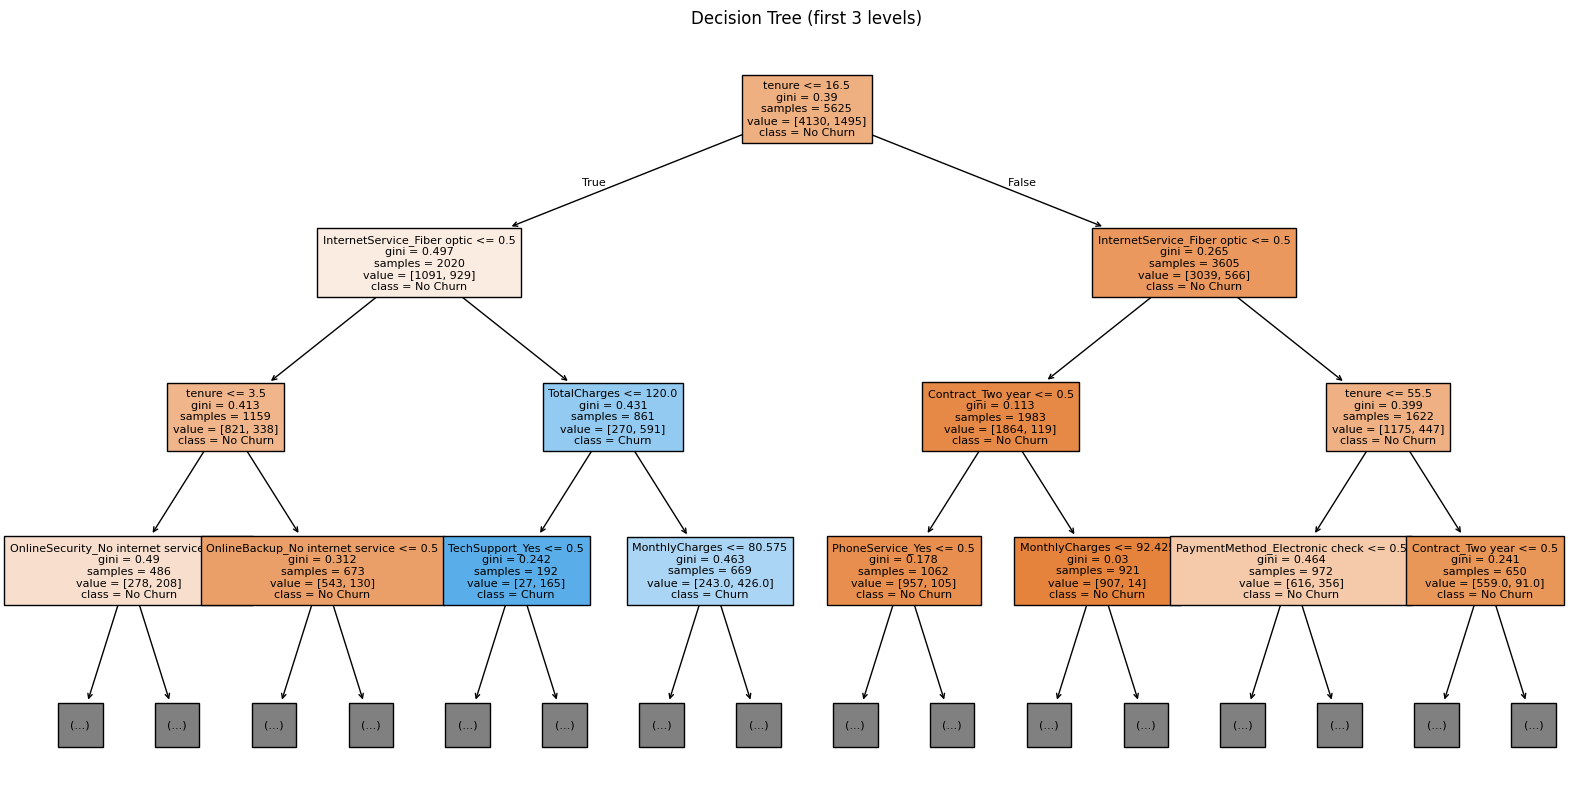

In [8]:
#visualization:
plt.figure(figsize=(20,10))
plot_tree(dt_model, max_depth=3, feature_names=X.columns, class_names=["No Churn", "Churn"],
          filled=True, fontsize=8)
plt.title("Decision Tree (first 3 levels)")
plt.show()

In [9]:
#Training random forest:

rf_model= RandomForestClassifier(n_estimators=100, random_state=42) #builds 100 trees and combines there votes
rf_model.fit(X_train, y_train)

y_pred_rf_train= rf_model.predict(X_train)
y_pred_rf_test= rf_model.predict(X_test)

train_acc_rf= accuracy_score(y_train, y_pred_rf_train)
test_acc_rf=accuracy_score(y_test, y_pred_rf_test)

print(f"Random Forest -> Train Acccuracy: {train_acc_rf: .4f}, Test Accuracy: {test_acc_rf:.4f}")


Random Forest -> Train Acccuracy:  0.9988, Test Accuracy: 0.7896


In [10]:
#Comparing both models
comparison= pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [train_acc_dt, train_acc_rf],
    "Test Accuracy": [test_acc_dt, test_acc_rf]
})

comparison


,Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.998756,0.718550
1,Random Forest,0.998756,0.789623


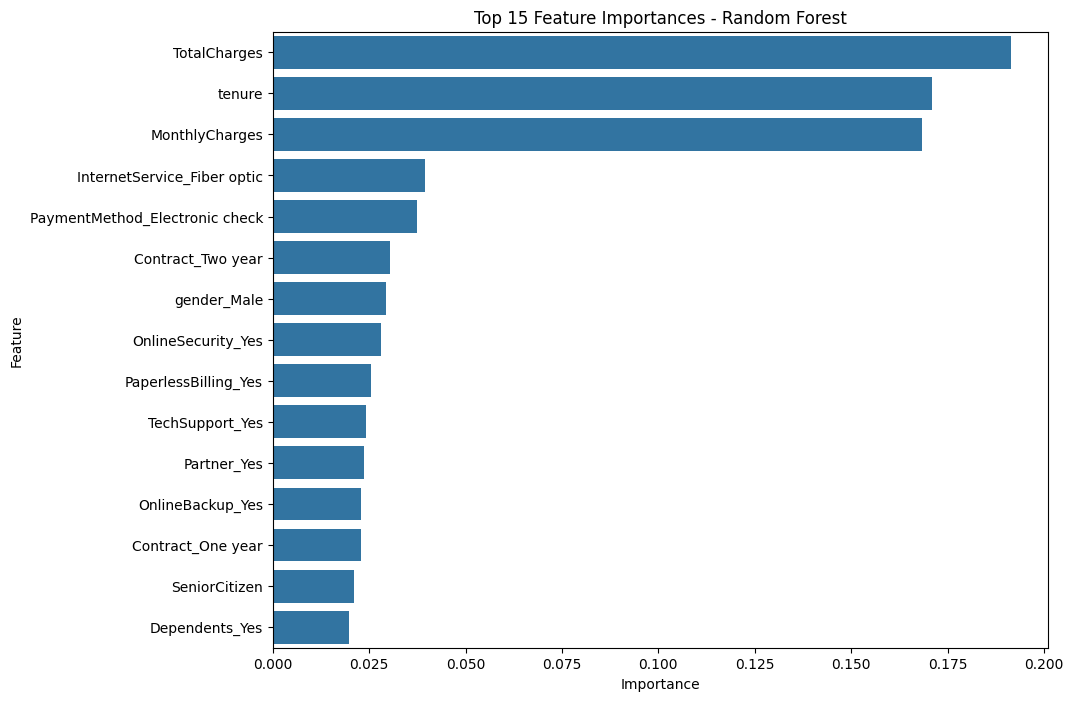

,Feature,Importance
3,TotalCharges,0.191435
1,tenure,0.171020
2,MonthlyCharges,0.168400
10,InternetService_Fiber optic,0.039481
28,PaymentMethod_Electronic check,0.037416
25,Contract_Two year,0.030529
4,gender_Male,0.029332
13,OnlineSecurity_Yes,0.028157
26,PaperlessBilling_Yes,0.025536
19,TechSupport_Yes,0.024114


In [11]:
#feature importance

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importances.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

importances.head(15)

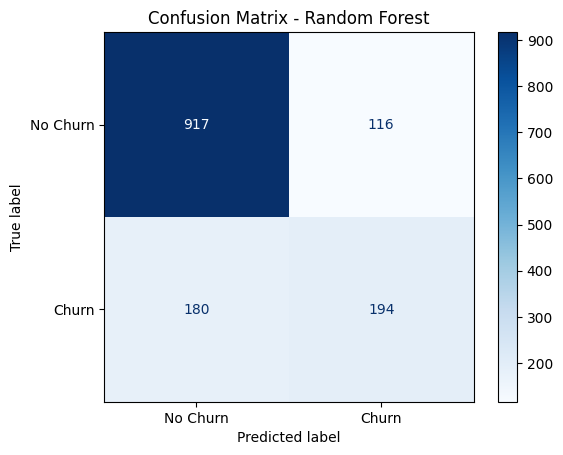

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [12]:
#confusion matrix:
cm = confusion_matrix(y_test, y_pred_rf_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(classification_report(y_test, y_pred_rf_test, target_names=["No Churn", "Churn"]))

# Experimenting to reduce overfitting

In [18]:
# Experiment: Reduce overfitting in Decision Tree by restricting its growth
# max_depth        -> limits how many levels deep the tree can split
# min_samples_leaf -> a leaf must have at least 20 samples (prevents tiny, overfit leaves)
# min_samples_split-> a node needs at least 40 samples before it's allowed to split further
dt_tuned = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)
dt_tuned.fit(X_train, y_train)

# Check accuracy on both train and test sets to measure the overfitting gap
train_acc_dt_tuned = accuracy_score(y_train, dt_tuned.predict(X_train))
test_acc_dt_tuned = accuracy_score(y_test, dt_tuned.predict(X_test))

print(f"Tuned Decision Tree -> Train: {train_acc_dt_tuned:.4f}, Test: {test_acc_dt_tuned:.4f}")

Tuned Decision Tree -> Train: 0.8101, Test: 0.7861


In [17]:
# Experiment: Apply the same depth/leaf restrictions to Random Forest's individual trees
# n_estimators     -> number of trees in the forest
# max_depth        -> restricts how deep each individual tree can grow
# min_samples_leaf -> forces each leaf to represent a reasonable chunk of data, not outliers
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

# Check accuracy on both train and test sets to measure the overfitting gap
train_acc_rf_tuned = accuracy_score(y_train, rf_tuned.predict(X_train))
test_acc_rf_tuned = accuracy_score(y_test, rf_tuned.predict(X_test))

print(f"Tuned Random Forest -> Train: {train_acc_rf_tuned:.4f}, Test: {test_acc_rf_tuned:.4f}")

Tuned Random Forest -> Train: 0.8212, Test: 0.7918


In [19]:
# Compare original (unrestricted) models vs tuned models

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (Before)", "Decision Tree (Tuned)",
        "Random Forest (Before)", "Random Forest (Tuned)"
    ],
    "Train Accuracy": [
        train_acc_dt, train_acc_dt_tuned,
        train_acc_rf, train_acc_rf_tuned
    ],
    "Test Accuracy": [
        test_acc_dt, test_acc_dt_tuned,
        test_acc_rf, test_acc_rf_tuned
    ]
})

# Overfitting gap = Train Accuracy - Test Accuracy (smaller gap = less overfitting)
comparison["Overfit Gap"] = comparison["Train Accuracy"] - comparison["Test Accuracy"]

comparison

,Model,Train Accuracy,Test Accuracy,Overfit Gap
0,Decision Tree (Before),0.998756,0.718550,0.280205
1,Decision Tree (Tuned),0.810133,0.786070,0.024064
2,Random Forest (Before),0.998756,0.789623,0.209132
3,Random Forest (Tuned),0.821156,0.791756,0.029400


# **Applying feature selection to further experiment with reducing overfitting**

In [20]:
# Step 1: Select features above an importance threshold
# (using the importances dataframe you already generated earlier)
threshold = 0.01
selected_features = importances[importances["Importance"] >= threshold]["Feature"].tolist()

print(f"Selected {len(selected_features)} out of {X.shape[1]} total features")
print(selected_features)

Selected 21 out of 30 total features
['TotalCharges', 'tenure', 'MonthlyCharges', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'gender_Male', 'OnlineSecurity_Yes', 'PaperlessBilling_Yes', 'TechSupport_Yes', 'Partner_Yes', 'OnlineBackup_Yes', 'Contract_One year', 'SeniorCitizen', 'Dependents_Yes', 'MultipleLines_Yes', 'DeviceProtection_Yes', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']


In [21]:
# Step 2: Rebuild X using only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Retrain Random Forest (same tuned settings as before) on the reduced feature set
rf_selected = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)
rf_selected.fit(X_train_selected, y_train)

train_acc_selected = accuracy_score(y_train, rf_selected.predict(X_train_selected))
test_acc_selected = accuracy_score(y_test, rf_selected.predict(X_test_selected))

print(f"RF (Feature-Selected) -> Train: {train_acc_selected:.4f}, Test: {test_acc_selected:.4f}")

RF (Feature-Selected) -> Train: 0.8222, Test: 0.7932


In [22]:
# Step 3: Comparing against  tuned (full-feature) Random Forest
comparison_fs = pd.DataFrame({
    "Model": ["RF (Tuned, All Features)", "RF (Tuned, Selected Features)"],
    "Num Features": [X_train.shape[1], len(selected_features)],
    "Train Accuracy": [train_acc_rf_tuned, train_acc_selected],
    "Test Accuracy": [test_acc_rf_tuned, test_acc_selected]
})
comparison_fs["Overfit Gap"] = comparison_fs["Train Accuracy"] - comparison_fs["Overfit Gap"] if False else comparison_fs["Train Accuracy"] - comparison_fs["Test Accuracy"]

comparison_fs

,Model,Num Features,Train Accuracy,Test Accuracy,Overfit Gap
0,"RF (Tuned, All Features)",30,0.821156,0.791756,0.029400
1,"RF (Tuned, Selected Features)",21,0.822222,0.793177,0.029045


## Key Takeaways

- Both Decision Tree and Random Forest were badly overfitting at first (train acc ~99.9% but test acc only 72-79%). Tuning max_depth, min_samples_leaf and min_samples_split fixed this almost completely — gap dropped from ~28% to ~2-3% for both models.
- Interesting finding: the tuned Decision Tree didn't just overfit less, its test accuracy actually went up (71.9% → 78.6%). So the untuned tree wasn't just "cheating" on training data, it was genuinely worse overall.
- Random Forest consistently did better than a single tree, which makes sense since bagging (averaging over many trees trained on random subsets) cancels out individual trees' mistakes.
- Feature importance showed tenure, TotalCharges and MonthlyCharges are by far the biggest drivers of churn (~53% combined importance) — makes sense intuitively, long-term low-paying customers behave very differently from new/high-paying ones.
- Tried dropping the 9 least important features (30 → 21) and accuracy barely changed at all. Not really a performance win, but it confirms the important features actually were the important ones, and gives a simpler/faster model for basically free.
- Biggest weakness overall: recall on the Churn class is only ~0.52, meaning almost half of customers who actually churn aren't being caught. Since accuracy overall is ~79%, this shows why accuracy alone is misleading here — precision/recall per class matters way more for this business problem. Next step would be trying class_weight="balanced" or SMOTE to specifically improve this.